# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Peter Taniwan
- **Email:** CDCC011D6Y2148@student.devacademy.id
- **ID Dicoding:** CDCC011D6Y2148

## Menentukan Pertanyaan Bisnis

Dalam proyek ini, prinsip **SMART** digunakan dalam menyusun pertanyaan bisnis supaya analisis data bisa terarah. Prinsip tersebut membuat pertanyaan harus spesifik (S), bisa diukur (M), mengarahkan untuk pengambilan keputusan (A), , relevan dengan konteks bisnis (R), dan memiliki batasan waktu yang jelas (T).

Dataset yang digunakan dalam analisis merupakan dataset transaksi e-commerce Olist pada tahun 2016-2018. Sehingga fokus analisis difokuskan pada **tren penjualan bulanan** dan **segmentasi pelanggan berdasarkan perilaku belanja**.

**Penerapan SMART Question pada proyek ini**

- **Specific:** analisis ditujukan pada performa penjualan dan perilaku pelanggan.
- **Measurable:** analisis diukur menggunakan angka jumlah pesanan, total pendapatan, dan RFM (Recency, Frequency, dan Monetary).
- **Action-Oriented:** hasil analisis dapat digunakan sebagai referensi untuk pembuatan strategi penjualan dan retensi/loyalitas pelanggan.
- **Relevant:** analisis tren penjualan dan segmentasi pelanggan merupakan aspek penting dalam bisnis e-commerce.
- **Time-bound:** tren penjualan dianalisis berdasarkan bulan transaksi dari periode dataset.

- **Pertanyaan 1:** Bagaimana tren performa penjualan e-commerce dari bulan ke bulan berdasarkan jumlah pesanan dan total pendapatan, lalu pada bulan apa penjualan tertinggi terjadi?
- **Pertanyaan 2:** Bagaimana segmentasi pelanggan berdasarkan perilaku belanjanya dengan RFM analysis lalu kelompok pelanggan mana yang paling berharga (Loyal/VIP) bagi bisnis?

## Import Semua Packages/Library yang Digunakan

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

#### Load dataset customer, orders, dan payments

Dataset yang digunakan disesuaikan dengan kebutuhan pertanyaan bisnis.

- `orders_dataset.csv`: bertujuan melihat waktu transaksi dan status pesanan.
- `order_payments_dataset.csv`: bertujuan menghitung pendapatan berdasarkan nilai pembayaran.
- `customers_dataset.csv`: bertujuan mengenali pelanggan melalui `customer_unique_id` pada RFM analysis.

In [16]:
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
payments_df = pd.read_csv("data/order_payments_dataset.csv")

print("Ukuran customers_df:", customers_df.shape)
print("Ukuran orders_df:", orders_df.shape)
print("Ukuran payments_df:", payments_df.shape)

display(customers_df.head())
display(orders_df.head())
display(payments_df.head())

Ukuran customers_df: (99441, 5)
Ukuran orders_df: (99441, 8)
Ukuran payments_df: (103886, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Dataset customers, orders, dan payments sudah memadai dalam menjawab pertanyaan bisnis (tren penjualan dan segmentasi pelanggan).
- Dataset masih dalam bentuk tabel terpisah sehingga perlu digabungkan menggunakan key fitur seperti `customer_id` dan `order_id`.
- 1 pesanan bisa memiliki lebih dari 1 baris pembayaran, sehingga data pembayaran perlu diagregasi terlebih dahulu sebelum digabungkan.

### Assessing Data

#### Identifying data quality problem

Pada tahap ini dilakukan pengecekan awal terhadap dataset mulai dari struktur data, tipe data, cakupan periode transaksi, hingga permasalahan data seperti missing value dan duplicate value.

In [17]:
print("Informasi customers_df")
customers_df.info()

print("\nInformasi orders_df")
orders_df.info()

print("\nInformasi payments_df")
payments_df.info()

print("\nJumlah duplicated values")
print("customers_df:", customers_df.duplicated().sum())
print("orders_df:", orders_df.duplicated().sum())
print("payments_df:", payments_df.duplicated().sum())

print("\nMissing values pada customers_df")
display(customers_df.isna().sum())

print("\nMissing valus pada orders_df")
display(orders_df.isna().sum())

print("\nMissing values pada payments_df")
display(payments_df.isna().sum())

print("\nDistribusi status pesanan")
display(orders_df["order_status"].value_counts())

Informasi customers_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Informasi orders_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purcha

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



Missing valus pada orders_df


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



Missing values pada payments_df


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0



Distribusi status pesanan


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Steps to Take:**
- Mengubah kolom tanggal pada data `orders_df` dari tipe object menjadi datetime.
- Melakukan agregasi data `payments_df` berdasarkan kolom `order_id` supaya setiap pesanan memiliki 1 nilai total pembayaran saja.
- Menggabungkan data order, customer, dan payment menggunakan `merge()`.
- Menggunakan pesanan berstatus `delivered` supaya analisis penjualan difokuskan pada transaksi yang sudah selesai.
- Membuat kolom `order_month` untuk kebutuhan analisis tren bulanan.
- Mempersiapkan data RFM berdasarkan `customer_unique_id`.

**Insight:**
- Beberapa kolom tanggal masih bertipe object sehingga perlu diubah menjadi datetime sebelum analisis lebih lanjut.
- Missing values pada tanggal pengiriman tidak langsung digunakan pada analisis ini, sebab fokus pertanyaan adalah bulan pembelian dan nilai transaksi.
- Perlu melakukan filter pada status pesanan supaya transaksi yang dianalisis lebih konsisten.

### Cleaning Data

#### Fixing data type, aggregation, merge, and filtering problem

Setelah asessing (mengenali) data termasuk permasalahannya, maka sekarang masuk ke proses memperbaikinya dengan data cleaning. Proses cleaning dilakukan dengan langkah sederhana yaitu **define, code, test**.

- **Define:** mengonversi tanggal, melakukan agregasi pembayaran, menggabungkan data, dan memilih transaksi yang selesai.
- **Code:** penerapan kode `pd.to_datetime()`, `groupby()`, `merge()`, dan  filtering pada dataset.
- **Test:** pengecekan ulang hasil cleaning dengan melihat bentuk data, missing value utama, dan preview data.

In [18]:
# Membuat salinan data agar data original tetap aman
orders_clean_df = orders_df.copy()
customers_clean_df = customers_df.copy()
payments_clean_df = payments_df.copy()

# Mengubah kolom tanggal dari object menjadi datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders_clean_df[column] = pd.to_datetime(orders_clean_df[column])

# Menggabungkan pembayaran berdasarkan order_id
payments_agg_df = payments_clean_df.groupby("order_id", as_index=False).agg({
    "payment_value": "sum"
})

# Menggabungkan data order dengan customer
order_customer_df = orders_clean_df.merge(
    customers_clean_df,
    on="customer_id",
    how="left"
)

# Menggabungkan data order-customer dengan payment
main_df = order_customer_df.merge(
    payments_agg_df,
    on="order_id",
    how="left"
)

# Menggunakan pesanan yang sudah selesai dikirim
main_df = main_df[main_df["order_status"] == "delivered"].copy()

# Menghapus baris yang tidak memiliki nilai pembayaran
main_df = main_df.dropna(subset=["payment_value"])

# Membuat kolom bulan transaksi
main_df["order_month"] = main_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

print("Ukuran main_df setelah cleaning:", main_df.shape)
print("\nTipe data setelah cleaning:")
print(main_df[["order_purchase_timestamp", "order_month", "payment_value"]].dtypes)

print("\nMissing value pada kolom utama:")
display(main_df[["order_id", "customer_unique_id", "order_purchase_timestamp", "payment_value", "order_month"]].isna().sum())

display(main_df.head())

Ukuran main_df setelah cleaning: (96477, 14)

Tipe data setelah cleaning:
order_purchase_timestamp    datetime64[ns]
order_month                         object
payment_value                      float64
dtype: object

Missing value pada kolom utama:


,0
order_id,0
customer_unique_id,0
order_purchase_timestamp,0
payment_value,0
order_month,0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,2018-02


**Insight:**
- Dataset utama telah disusun dalam level order sehingga lebih aman digunakan dalam menghitung jumlah pesanan dan total pendapatan.
- Kolom `order_month` sudah siap digunakan dalam membuat tren penjualan bulanan.
- Status pesanan `delivered`digunakan supaya analisis lebih fokus pada transaksi yang sudah selesai.

## Exploratory Data Analysis (EDA)

### Explore tren bulanan dan data pelanggan

Pada tahap EDA, data dieksplorasi dengan descriptive statistics dan `groupby()` untuk membaca pola utama data sebelum tahap visualisasi.

In [19]:
print("Ringkasan Statistik deskriptif nilai pembayaran")
display(main_df["payment_value"].describe())

print("\nPeriode transaksi yang dianalisis")
print("Mulai:", main_df["order_purchase_timestamp"].min())
print("Selesai:", main_df["order_purchase_timestamp"].max())

# Membuat tabel tren penjualan bulanan
monthly_sales_df = main_df.groupby("order_month", as_index=False).agg({
    "order_id": "nunique",
    "payment_value": "sum"
})

monthly_sales_df = monthly_sales_df.rename(columns={
    "order_id": "total_order",
    "payment_value": "total_revenue"
})

monthly_sales_df["order_month_date"] = pd.to_datetime(monthly_sales_df["order_month"])

display(monthly_sales_df.head())

# Melihat bulan dengan performa tertinggi
top_order_month = monthly_sales_df.sort_values("total_order", ascending=False).head(1)
top_revenue_month = monthly_sales_df.sort_values("total_revenue", ascending=False).head(1)

print("\nBulan dengan jumlah pesanan tertinggi:")
display(top_order_month[["order_month", "total_order", "total_revenue"]])

print("\nBulan dengan total pendapatan tertinggi:")
display(top_revenue_month[["order_month", "total_order", "total_revenue"]])

# Menyiapkan data untuk analisis RFM
snapshot_date = main_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = main_df.groupby("customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
})

rfm_df = rfm_df.rename(columns={
    "order_purchase_timestamp": "recency",
    "order_id": "frequency",
    "payment_value": "monetary"
})

print("\nPreview data RFM")
display(rfm_df.head())

print("\nStatistik deskriptif RFM")
display(rfm_df[["recency", "frequency", "monetary"]].describe())

Ringkasan Statistik deskriptif nilai pembayaran


,payment_value
count,96477.000000
mean,159.856357
std,218.813144
min,9.590000
25%,61.880000
50%,105.280000
75%,176.330000
max,13664.080000



Periode transaksi yang dianalisis
Mulai: 2016-10-03 09:44:50
Selesai: 2018-08-29 15:00:37


,order_month,total_order,total_revenue,order_month_date
0,2016-10,265,46566.71,2016-10-01
1,2016-12,1,19.62,2016-12-01
2,2017-01,750,127545.67,2017-01-01
3,2017-02,1653,271298.65,2017-02-01
4,2017-03,2546,414369.39,2017-03-01



Bulan dengan jumlah pesanan tertinggi:


...

,order_month,total_order,total_revenue
12,2017-11,7289,1153528.05



Preview data RFM


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89



Statistik deskriptif RFM


,recency,frequency,monetary
count,93357.000000,93357.000000,93357.000000
mean,237.936673,1.033420,165.198772
std,152.584315,0.209099,226.314579
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.060000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.560000
max,695.000000,15.000000,13664.080000


**Insight:**
- Penggunaan `order_month` memungkinkan data penjualan dapat dianalisis pada level bulanan.
- Bulan dengan total pesanan dan pendapatan tertinggi dapat dibandingkan dalam memahami tren penjualan.
- Nilai `frequency` pada RFM memberitahukan bahwa banyak pelanggan hanya melakukan pembelian 1 kali, sehingga segmentasi pelanggan perlu dibuat dengan aturan yang sederhana dan mudah dijelaskan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

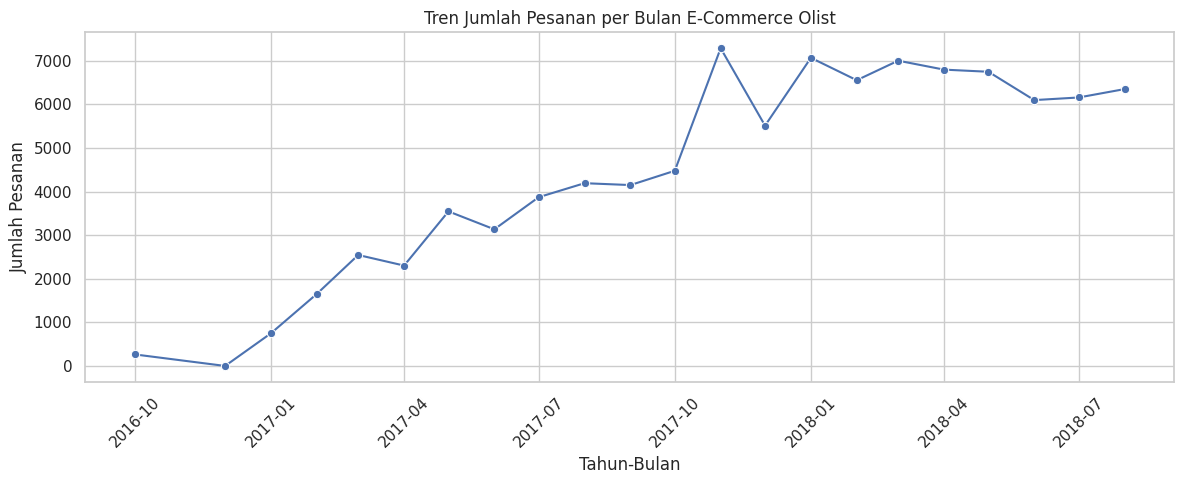

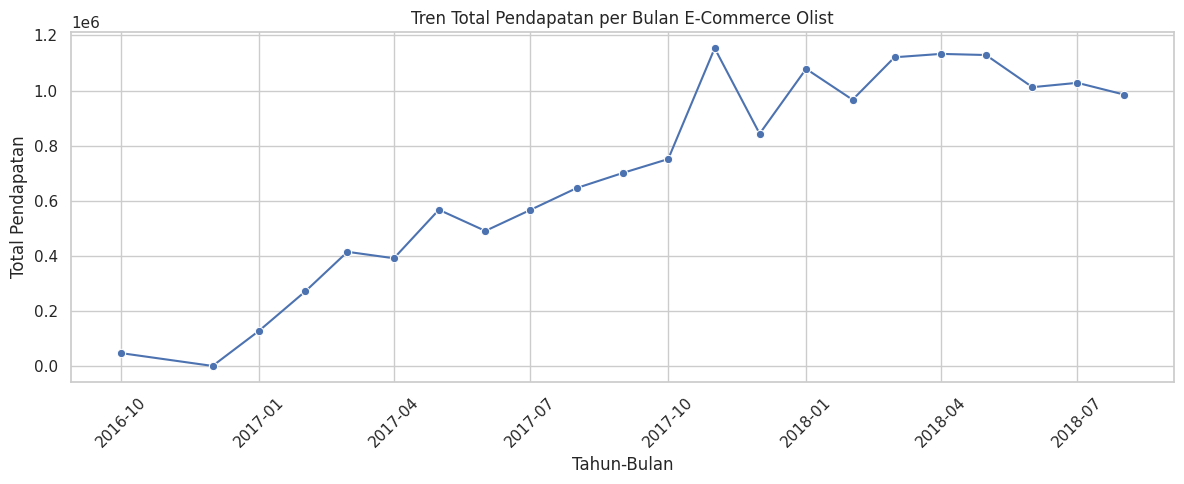

Bulan dengan jumlah pesanan tertinggi:


,order_month,total_order,total_revenue
12,2017-11,7289,1153528.05


Bulan dengan total pendapatan tertinggi:


,order_month,total_order,total_revenue
12,2017-11,7289,1153528.05


In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_sales_df,
    x="order_month_date",
    y="total_order",
    marker="o"
)
plt.title("Tren Jumlah Pesanan per Bulan E-Commerce Olist")
plt.xlabel("Tahun-Bulan")
plt.ylabel("Jumlah Pesanan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_sales_df,
    x="order_month_date",
    y="total_revenue",
    marker="o"
)
plt.title("Tren Total Pendapatan per Bulan E-Commerce Olist")
plt.xlabel("Tahun-Bulan")
plt.ylabel("Total Pendapatan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Bulan dengan jumlah pesanan tertinggi:")
display(top_order_month[["order_month", "total_order", "total_revenue"]])

print("Bulan dengan total pendapatan tertinggi:")
display(top_revenue_month[["order_month", "total_order", "total_revenue"]])

### Pertanyaan 2:

,customer_segment,total_customer,avg_recency,avg_frequency,avg_monetary,total_monetary
2,Loyal / VIP Customer,141,105.723404,3.553191,542.109362,76437.42
1,High Value but Inactive,80,351.637500,3.150000,482.271750,38581.74
0,At Risk Customer,1172,353.190273,2.005973,288.607705,338248.23
4,Potential Loyalist,23780,112.082044,1.052061,264.350297,6286250.07
5,Regular Customer,45258,364.952561,1.000000,159.868042,7235307.83
3,New Customer,22926,112.263064,1.007459,63.143875,1447636.48


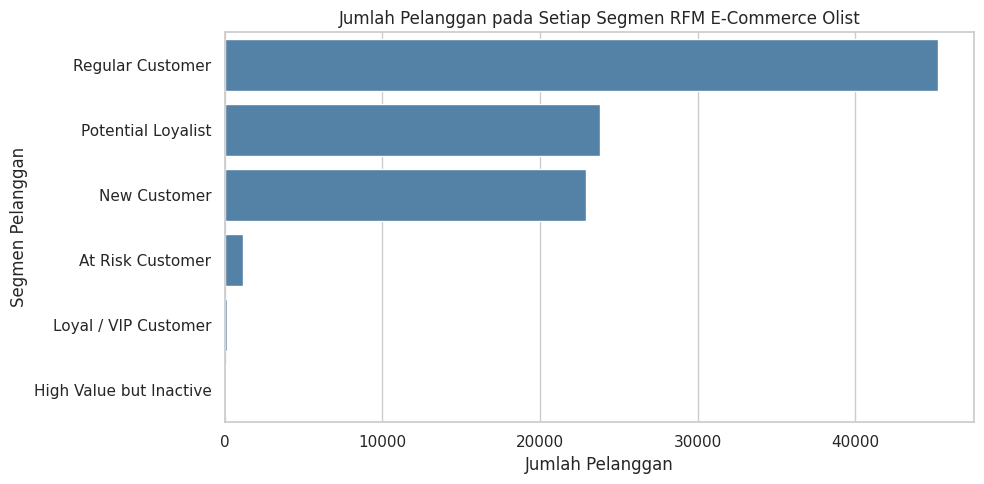

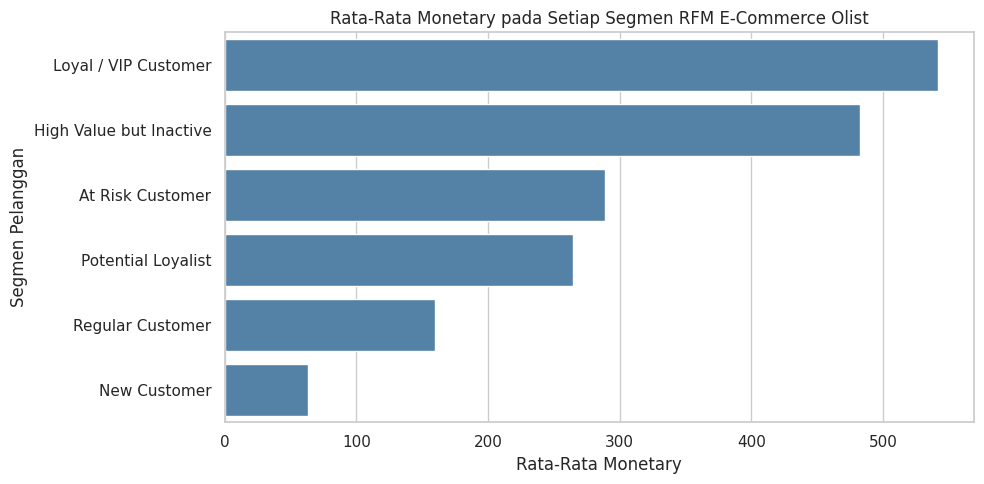

In [21]:
# Memberikan skor Recency
# Semakin kecil recency, semakin baik nilainya
rfm_df["r_score"] = pd.qcut(
    rfm_df["recency"],
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)

# Memberikan skor Frequency dengan manual grouping
# karena mayoritas customer hanya memiliki 1 transaksi
def give_frequency_score(frequency):
    if frequency == 1:
        return 1
    elif frequency == 2:
        return 2
    elif frequency <= 4:
        return 3
    else:
        return 4

rfm_df["f_score"] = rfm_df["frequency"].apply(give_frequency_score)

# Memberikan skor Monetary
# Semakin besar monetary, semakin baik nilainya
rfm_df["m_score"] = pd.qcut(
    rfm_df["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm_df["rfm_score"] = (
    rfm_df["r_score"].astype(str)
    + rfm_df["f_score"].astype(str)
    + rfm_df["m_score"].astype(str)
)

def make_customer_segment(row):
    if row["r_score"] >= 3 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "Loyal / VIP Customer"
    elif row["r_score"] >= 3 and row["m_score"] >= 3:
        return "Potential Loyalist"
    elif row["r_score"] >= 3:
        return "New Customer"
    elif row["f_score"] >= 3 and row["m_score"] >= 3:
        return "High Value but Inactive"
    elif row["r_score"] <= 2 and row["f_score"] >= 2:
        return "At Risk Customer"
    else:
        return "Regular Customer"

rfm_df["customer_segment"] = rfm_df.apply(make_customer_segment, axis=1)

segment_summary_df = rfm_df.groupby("customer_segment", as_index=False).agg({
    "customer_unique_id": "count",
    "recency": "mean",
    "frequency": "mean",
    "monetary": ["mean", "sum"]
})

segment_summary_df.columns = [
    "customer_segment",
    "total_customer",
    "avg_recency",
    "avg_frequency",
    "avg_monetary",
    "total_monetary"
]

segment_summary_df = segment_summary_df.sort_values("avg_monetary", ascending=False)

display(segment_summary_df)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=segment_summary_df.sort_values("total_customer", ascending=False),
    x="total_customer",
    y="customer_segment",
    color="steelblue"
)
plt.title("Jumlah Pelanggan pada Setiap Segmen RFM E-Commerce Olist")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen Pelanggan")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=segment_summary_df,
    x="avg_monetary",
    y="customer_segment",
    color="steelblue"
)
plt.title("Rata-Rata Monetary pada Setiap Segmen RFM E-Commerce Olist")
plt.xlabel("Rata-Rata Monetary")
plt.ylabel("Segmen Pelanggan")
plt.tight_layout()
plt.show()

**Insight:**
- Pada pertanyaan 1, tren penjualan menunjukkan sebuah kenaikan performa yang cukup jelas dari awal periode menuju tahun 2017 dan 2018.
- Bulan dengan jumlah pesanan dan total pendapatan tertinggi  adalah **2017-11**.
- Pada pertanyaan 2, segmen **Loyal / VIP Customer** memiliki rata-rata monetary tertinggi, sehingga segmen ini dapat diasumsikan sebagai kelompok pelanggan paling berharga.
- Meskipun begitu, segmen lain dengan jumlah pelanggan yang tinggi tetap dipertimbangkan karena memberikan kontribusi pendapatan total yang tinggi juga.

## Analisis Lanjutan (Opsional)

Analisis lanjutan yang digunakan adalah **RFM Analysis**. Analisis ini relevan karena mampu mengelompokkan pelanggan berdasarkan perilaku belanja. Analisis ini mempertimbangkan 3 aspek yaitu:
1. **Recency:** jumlah hari sejak pelanggan terakhir melakukan transaksi.
2. **Frequency:** jumlah transaksi yang dilakukan pelanggan.
3. **Monetary:** total nilai transaksi pelanggan.

Dalam proyek ini, RFM digunakan untuk membantu e-commerce dalam melihat kelompok pelanggan yang perlu dipertahankan, dikembangkan, atau diaktifkan kembali.

In [22]:
# Melihat segmen paling berharga berdasarkan rata-rata monetary
most_valuable_segment_df = segment_summary_df.sort_values("avg_monetary", ascending=False).head(3)
display(most_valuable_segment_df)

# Menyimpan data hasil analisis untuk kebutuhan dashboard Streamlit
os.makedirs("dashboard", exist_ok=True)

main_df.to_csv("dashboard/main_data.csv", index=False)
monthly_sales_df.to_csv("dashboard/monthly_sales.csv", index=False)
rfm_df.to_csv("dashboard/rfm_data.csv", index=False)
segment_summary_df.to_csv("dashboard/segment_summary.csv", index=False)

print("Data untuk dashboard berhasil disimpan.")

,customer_segment,total_customer,avg_recency,avg_frequency,avg_monetary,total_monetary
2,Loyal / VIP Customer,141,105.723404,3.553191,542.109362,76437.42
1,High Value but Inactive,80,351.637500,3.150000,482.271750,38581.74
0,At Risk Customer,1172,353.190273,2.005973,288.607705,338248.23


Data untuk dashboard berhasil disimpan.


**Insight:**
- RFM analysis menunjukkan bahwa pelanggan dengan kombinasi recency, frequency, dan monetary tinggi adalah segmen **Loyal / VIP Customer**.
- Segmen ini penting dipertahankan karena memiliki rata-rata nilai transaksi tertinggi.
- Segmen **Potential Loyalist** juga perlu dikembangkan karena memiliki nilai transaksi tinggi, meskipun belum sepenuhnya masuk kategori loyal/VIP.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Tren penjualan e-commerce bersifat positif dan mengalami kenaikan dari bulan ke bulan meskipun fluktuatif. Berdasarkan data pesanan dengan status `delivered`, bulan dengan jumlah pesanan dan total pendapatan tertinggi adalah **2017-11** dengan **7.289 pesanan** dan total pendapatan sekitar **1.153.528**.
- **Conclusion pertanyaan 2:** Berdasarkan RFM analysis, segmen **Loyal / VIP Customer** menjadi kelompok pelanggan paling berharga karena memiliki rata-rata monetary tertinggi. Meskipun begitu, segmen dengan jumlah pelanggan besar seperti Regular Customer tetap perlu dipertimbangkan karena bisa  memberi kontribusi total pendapatan yang besar.

**Rekomendasi Action Item:**
- Menggunakan bulan dengan performa tinggi sebagai acuan dalam mengevaluasi faktor pendorong penjualan, seperti campaign, promo, atau momentum belanja tertentu.
- Menyiapkan strategi promosi menjelang bulan dengan potensi penjualan tinggi supaya potensi penjualan dapat dimaksimalkan.
- Memberikan program loyalty, voucher khusus, atau early access promo kepada segmen **Loyal / VIP Customer**.
- Mengembangkan segmen **Potential Loyalist** agar naik menjadi pelanggan Loyal/VIP.
- Membuat campaign reactivation dengan hadiah menarik kepada pelanggan yang berada pada segmen **At Risk Customer** atau **High Value but Inactive**.